# 10.7.1 相同信息下的控制评价

## 学习目标与先修知识

在相同观测（observation）、限幅和扰动下报告跟踪、代价和失败。

先修：10.1—10.6的反馈（feedback）、估计与约束方法；第6.5章独立验证。

## 具体问题

哪一种控制器“最好”？若一法能看到真值、另一法只能看到带噪读数，或一法没执行器上限，比较结果不能归因于算法。先固定信息和执行接口，再看跟踪、输入（input）和失败。

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先为一条固定轨迹（trajectory）计算平均平方跟踪误差、实际输入平方成本和超限量，确认这三项不是同一个指标。

In [2]:
states=[1.,.5,0.];goals=[0.,0.,0.];controls=[2.,1.];print("跟踪MSE、输入MSE、最大超限：",sum((x-r)**2 for x,r in zip(states,goals))/3,sum(u*u for u in controls)/2,max(max(0,abs(u)-1.5) for u in controls))

跟踪MSE、输入MSE、最大超限： 0.4166666666666667 2.5 0.5


## 模型假设

人工标量温度偏差对象 $x^+=0.9x+0.8u+d$，目标1 U，真实输入限幅±1。三法获得同一场景的读数 $y=x+v$、扰动d和初态；PID直接使用y，基于状态（state）的方法使用同一简化估计接口 $\hat x\leftarrow0.7y+0.3\hat x_{pred}$。这是教学滤波器而非第7篇的Kalman最优估计。比较只在固定调参和此模型（model）条件下成立。

## 数学解释与推导

公平对比须列出任务、观测、执行约束、初态、扰动序列、计算预算、调参数（parameter）据及独立评价条件。对每个成功场景记录
$$E=\frac1{T+1}\sum_{t=0}^T(x_t-r_t)^2,\quad U=\frac1T\sum_{t=0}^{T-1}u_{actual,t}^2,\quad V=\max_t(0,|u_{actual,t}|-u_{max}).$$
实际输入进入动力学和成本，不是未裁剪请求。求解失败要单独计数，不能因为没有完整轨迹就从分母中消失。

本节LQR反馈仅在偏差坐标上使用，另加维持目标的平衡（equilibrium）输入 $u_{eq}=(1-0.9)r/0.8$，这是防止把调零模型直接用于非零目标的必要修正。MPC使用离散行动集合，只是小模型的枚举基线，计算预算与连续MPC不同。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def pi_step(error, integral, dt, kp, ki, limit):
    """Conditional integration: freeze I only when saturation would deepen."""
    proposed = integral + error * dt
    requested = kp * error + ki * proposed
    actual = max(-limit, min(limit, requested))
    if actual != requested and error * requested > 0:
        proposed = integral
        requested = kp * error + ki * proposed
        actual = max(-limit, min(limit, requested))
    return requested, actual, proposed


def scalar_bellman(a, b, q, r, terminal, state):
    denominator = r + b * b * terminal
    gain = b * terminal * a / denominator
    value_weight = q + a * a * terminal - (a * b * terminal) ** 2 / denominator
    return -gain * state, value_weight * state * state, value_weight


def discrete_mpc(state, a, b, target, q, r, terminal, actions, horizon, lower, upper):
    """Exact enumeration of a small *discrete-action* MPC, not continuous MPC."""
    best = None
    for sequence in itertools.product(actions, repeat=horizon):
        x = state
        cost = 0.0
        path = [x]
        for u in sequence:
            cost += q * (x - target) ** 2 + r * u * u
            x = a * x + b * u
            path.append(x)
            if not lower <= x <= upper:
                break
        else:
            cost += terminal * (x - target) ** 2
            candidate = (cost, sequence, path)
            if best is None or candidate[:2] < best[:2]:
                best = candidate
    if best is None:
        return 'infeasible', None, None, []
    cost, sequence, path = best
    return 'optimal', sequence[0], cost, path


def paired_metrics(targets, trajectories, applied, limit, failed):
    """One scenario; failed still counts in the denominator outside this helper."""
    if failed:
        return None, None, None, True
    error = sum((x - goal) ** 2 for x, goal in zip(trajectories, targets)) / len(targets)
    effort = sum(u * u for u in applied) / len(applied) if applied else 0.0
    violation = max([max(0.0, abs(u) - limit) for u in applied] or [0.0])
    return error, effort, violation, False

## 对照实验

使用一组固定读数噪声和扰动比较PI、带同一估计器的LQR反馈与离散行动MPC。图示真实状态和实际执行输入，表中报告指标与失败。

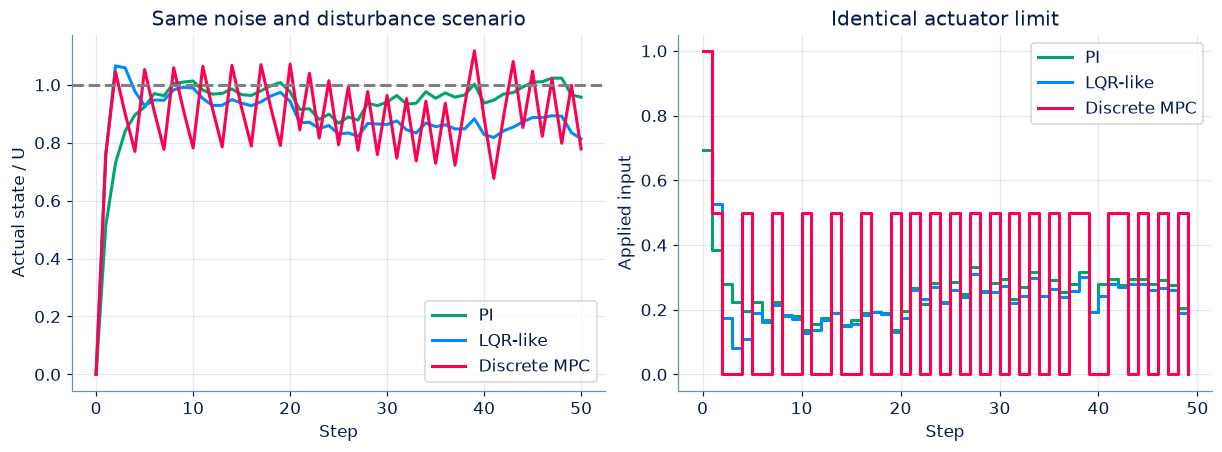

| 方法 | 跟踪 MSE / U² | 输入 MSE | 最大超限 | 失败 |
| --- | --- | --- | --- | --- |
| PI | 0.0291315 | 0.0693164 | 0 | 0 |
| LQR-like | 0.0343543 | 0.07409 | 0 | 0 |
| Discrete MPC | 0.0435934 | 0.13 | 0 | 0 |

In [4]:
rng=np.random.default_rng(1071);T=50;noise=rng.normal(0,.035,T);disturbance=-.04+np.r_[np.zeros(20),np.full(30,-.08)]
ueq=(1-.9)/.8;gain=-scalar_bellman(.9,.8,1.,.3,3.,1.)[0]
results={};fig,axes=plt.subplots(1,2,figsize=(11,4))
for method,color in [('PI',GREEN),('LQR-like',BLUE),('Discrete MPC',PINK)]:
    x=0.;estimate=0.;integral=0.;states=[x];controls=[];failed=False
    for t in range(T):
        y=x+noise[t]
        estimate=.7*y+.3*estimate
        if method=='PI':_,u,integral=pi_step(1.-y,integral,1.,.65,.08,1.)
        elif method=='LQR-like':u=float(np.clip(ueq-gain*(estimate-1.),-1.,1.))
        else:
            status,u,_,_=discrete_mpc(estimate,.9,.8,1.,1.,.3,3.,[-1.,-.5,0.,.5,1.],3,-1.,2.)
            if status!='optimal':failed=True;break
        controls.append(u);x=.9*x+.8*u+disturbance[t];states.append(x)
    metrics=paired_metrics([1.]*len(states),states,controls,1.,failed)
    results[method]=metrics
    axes[0].plot(states,label=method,color=color);axes[1].step(range(len(controls)),controls,where='post',label=method,color=color)
axes[0].axhline(1,color='gray',ls='--');axes[0].set(xlabel='Step',ylabel='Actual state / U',title='Same noise and disturbance scenario');axes[0].legend()
axes[1].set(xlabel='Step',ylabel='Applied input',title='Identical actuator limit');axes[1].legend();plt.show()
display(Markdown(show_table(['方法','跟踪 MSE / U²','输入 MSE','最大超限','失败'],[(name,*values) for name,values in results.items()])))

## 结果解释

不同方法在同一外部场景下可出现不同误差与执行代价。估计器、增益（gain）和行动集在比较前固定，接下来再改变外部场景考察排序是否保持。表中失败字段始终保留；若MPC不可行，应报告这一事实，而不是把它当成0成本。

### 独立核对

独立重算表中的 PI 指标，并检查各成功方法的实际输入是否满足共同限幅。

In [5]:
assert all(v[2] is None or v[2]<=1e-12 for v in results.values())
assert all(v[3] in (True,False) for v in results.values())
assert np.isclose(gain,-scalar_bellman(.9,.8,1.,.3,3.,1.)[0])
print('指标结构、平衡输入与共同执行上限通过。')

指标结构、平衡输入与共同执行上限通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-07-%E4%BC%B0%E8%AE%A1%E5%8F%8D%E9%A6%88%E4%B8%8E%E9%97%AD%E7%8E%AF%E9%AA%8C%E8%AF%81/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算一个闭环场景的指标

对一个已完成场景计算平均平方跟踪误差、平均平方实际执行输入（input）、最大输入超限量及失败标记。失败场景仍返回标记，数值指标为None，不得把它从总场景数中消失。

**函数与代码模板**

```python
def solve(
    targets: list[float],
    trajectories: list[float],
    applied: list[float],
    limit: float,
    failed: bool,
) -> tuple[float | None, float | None, float | None, bool]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `targets` | `list[float]` | 与轨迹（trajectory）等长的目标。 | U |
| `trajectories` | `list[float]` | 按时刻记录的实际状态（state）。 | U |
| `applied` | `list[float]` | 实际执行输入，可为空。 | 输入单位 |
| `limit` | `float` | 允许的输入绝对值上限。 | 输入单位 |
| `failed` | `bool` | 求解、估计或安全检查是否失败。 | 不适用 |

**返回值**

按以下顺序返回元组：(tracking_mse, effort_mse, max_violation, failure)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `tracking_mse` | <code>float &#124; None</code> | 未失败时平均平方误差。 | U² |
| `effort_mse` | <code>float &#124; None</code> | 未失败时平均平方实际输入。 | 输入² |
| `max_violation` | <code>float &#124; None</code> | 未失败时最大max(0,&#124;u&#124;−limit)。 | 输入单位 |
| `failure` | `bool` | 原样保留失败。 | 不适用 |

**计算规则**

失败时返回(None,None,None,True)；否则分别按序列长度平均，空applied的努力为0、超限为0。

**约束与边界**

- targets非空且与trajectories等长，0≤长度≤200；limit>0；数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| targets | 与轨迹（trajectory）等长的目标。 | [0.0, 0.0, 0.0] | U |
| trajectories | 按时刻记录的实际状态（state）。 | [1.0, 0.5, 0.0] | U |
| applied | 实际执行输入，可为空。 | [2.0, 1.0] | 输入单位 |
| limit | 允许的输入绝对值上限。 | 1.5 | 输入单位 |
| failed | 求解、估计或安全检查是否失败。 | False | 不适用 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
targets = [0.0, 0.0, 0.0]
trajectories = [1.0, 0.5, 0.0]
applied = [2.0, 1.0]
limit = 1.5
failed = False

result = solve(targets, trajectories, applied, limit, failed)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| tracking_mse | 未失败时平均平方误差。 | ≈ 0.4166667 | U² |
| effort_mse | 未失败时平均平方实际输入。 | 2.5 | 输入² |
| max_violation | 未失败时最大max(0,|u|−limit)。 | 0.5 | 输入单位 |
| failure | 原样保留失败。 | False | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.4166666666666667, 2.5, 0.5, False)
```

**样例解释**

首例跟踪MSE为(1+0.25)/3，实际输入代价为(4+1)/2，最大超限0.5。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算一个闭环场景的指标](http://127.0.0.1:8000/chapters/10-07-%E4%BC%B0%E8%AE%A1%E5%8F%8D%E9%A6%88%E4%B8%8E%E9%97%AD%E7%8E%AF%E9%AA%8C%E8%AF%81/practice/?question=p10-scenario-metrics)

### 第 2 题 · 单项选择题：公平控制比较

PID、LQR 与 MPC 比较时，LQR 和 MPC 需要状态（state）估计。哪种协议最公平？

- **A.** 三法共享观测（observation）、执行上限、扰动场景与调参预算；需要状态的两法共享同一估计器。
- **B.** 只给LQR完整隐藏状态，却称三法信息相同。
- **C.** 为MPC删去求解超时场景。
- **D.** 各法分别选对自己最有利的测试扰动。

[作答：公平控制比较](http://127.0.0.1:8000/chapters/10-07-%E4%BC%B0%E8%AE%A1%E5%8F%8D%E9%A6%88%E4%B8%8E%E9%97%AD%E7%8E%AF%E9%AA%8C%E8%AF%81/practice/?question=p10-fair-baseline)

### 第 3 题 · 单项选择题：平均误差之外

两个控制器平均跟踪误差相近；方法A偶尔严重超限，方法B始终可行。应报告什么？

- **A.** 跟踪误差、实际输入（input）成本、约束违反、失败率及其场景分布（distribution）。
- **B.** 只报告平均跟踪误差。
- **C.** 删掉A的超限值再取平均。
- **D.** 把请求输入当成真实执行输入。

[作答：平均误差之外](http://127.0.0.1:8000/chapters/10-07-%E4%BC%B0%E8%AE%A1%E5%8F%8D%E9%A6%88%E4%B8%8E%E9%97%AD%E7%8E%AF%E9%AA%8C%E8%AF%81/practice/?question=p10-average-not-enough)

### 第 4 题 · 单项选择题：调参场景可再次作证吗

某控制器用一批扰动场景反复调参。哪项说法成立？

- **A.** 同批场景上的成绩属于调参/拟合表现，独立评价应使用未参与调参的场景。
- **B.** 只要重新估一次参数（parameter），同一场景就变成新实验。
- **C.** 每换一个图表样式，原场景都变成独立测试。
- **D.** 独立测试可以看到结果后反复改控制器且仍称未使用。

[作答：调参场景可再次作证吗](http://127.0.0.1:8000/chapters/10-07-%E4%BC%B0%E8%AE%A1%E5%8F%8D%E9%A6%88%E4%B8%8E%E9%97%AD%E7%8E%AF%E9%AA%8C%E8%AF%81/practice/?question=p10-training-vs-test)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。 [MIT Underactuated Robotics：Linear Quadratic Regulators](https://underactuated.mit.edu/lqr.html)：动态规划、LQR 与有约束控制的边界；本教材的离散行动例由此处的教学目标独立设计。